# RSI + Bollinger Band Strategy
_Assess both the momentum and volatility of a price_

### Import Library + Data

In [36]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set our time window (factor in the 50 day waiting period for SMA to kick in)
start_date = '2020-10-12'
end_date = '2021-12-30'
 
# Type in any ticker to analyze its behavior against our SMA strategy
ticker = 'TSLA'
df = yf.download(ticker, start_date, end_date)


# For our purposes, we only want the closing prices
df = df[['Close']].dropna()
df['Close'] = df['Close'].values.flatten()

# 20-day Simple Moving Average
df['SMA'] = df['Close'].rolling(window=20).mean()

# 20-day Standard Deviation
df['STDDEV'] = df['Close'].rolling(window=20).std()

# Upper and Lower Bollinger Bands
df['Upper_Band'] = df['SMA'] + (2 * df['STDDEV'])
df['Lower_Band'] = df['SMA'] - (2 * df['STDDEV'])

[*********************100%***********************]  1 of 1 completed


### Calculate RSI

In [37]:
# Price change from previous close
delta = df['Close'].diff()

# Positive gains (clip negatives to 0)
gain = delta.clip(lower=0)

# Negative losses (clip positives to 0, take negative)
loss = -delta.clip(upper=0)

# 14-day averages of gain/loss
avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

# Relative Strength
rs = avg_gain / avg_loss

# RSI calculation
df['RSI'] = 100 - (100 / (1 + rs))

df = df.iloc[20:]

### Buy/Sell Conditions

In [38]:
# First create neutral Signals
df['Signal'] = 0

# Buy when Buy Condition becomes newly true
buy_signal = (df['RSI'] < 30) & (df['Close'][ticker] <= df['Lower_Band'])
sell_signal = (df['RSI'] > 70) & (df['Close'][ticker] >= df['Upper_Band'])

# Entry only on transition
df.loc[(buy_signal) & (~(buy_signal.shift(1).fillna(False))), 'Signal'] = 1
df.loc[(sell_signal) & (~(sell_signal.shift(1).fillna(False))), 'Signal'] = -1

# Forward fill Position
df['Position'] = df['Signal']
df['Position'] = df['Position'].ffill()

C:\Users\tobys\AppData\Local\Temp\ipykernel_41052\2710308062.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[(buy_signal) & (~(buy_signal.shift(1).fillna(False))), 'Signal'] = 1
C:\Users\tobys\AppData\Local\Temp\ipykernel_41052\2710308062.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[(sell_signal) & (~(sell_signal.shift(1).fillna(False))), 'Signal'] = -1


### Plot Trends

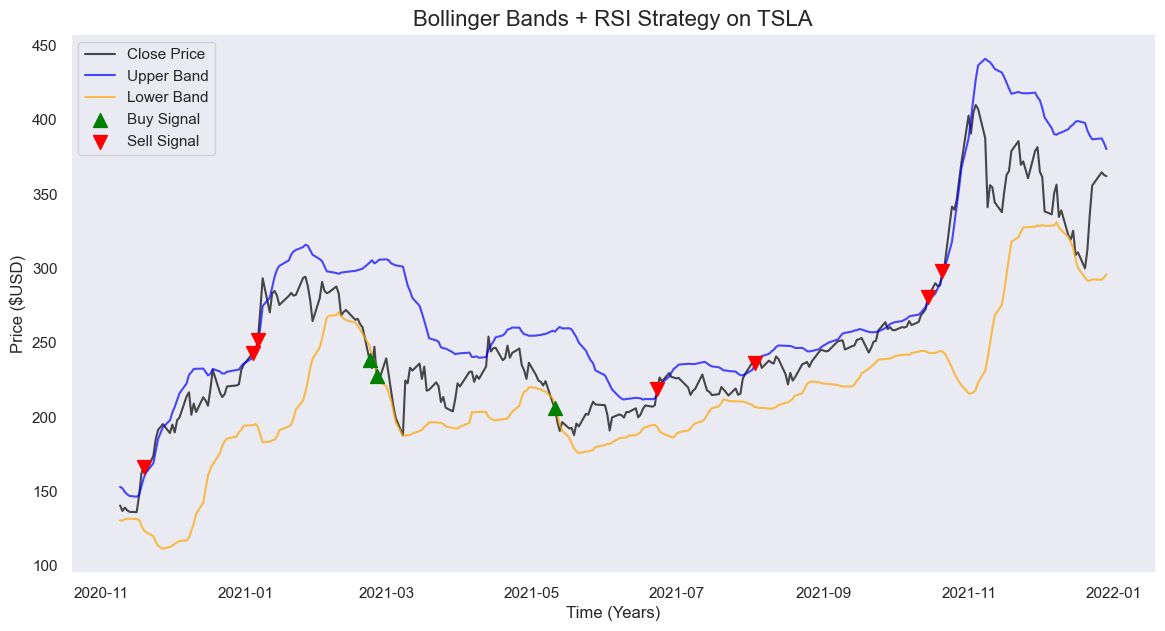

In [39]:
plt.figure(figsize=(14, 7))

# Plot Close price
plt.plot(df['Close'][ticker], label='Close Price', alpha=0.7, color='black', zorder=0)

# Plot Bollinger Bands
plt.plot(df['Upper_Band'], label='Upper Band', alpha=0.7, color='blue', zorder=5)
plt.plot(df['Lower_Band'], label='Lower Band', alpha=0.7, color='orange', zorder=5)

# Grid and labels
plt.grid()
plt.xlabel('Time (Years)')
plt.ylabel('Price ($USD)')

# Mark Buy & Sell signals
plt.scatter(
    df.index[df['Position'] ==  1],
    df['Close'][ticker][df['Position'] == 1],
    label='Buy Signal', marker='^', color='green', s=100, zorder=15
)
plt.scatter(
    df.index[df['Position'] == -1],
    df['Close'][ticker][df['Position'] == -1],
    label='Sell Signal', marker='v', color='red', s=100, zorder=20
)

# Title and Legend
plt.title(f"Bollinger Bands + RSI Strategy on {ticker}", fontsize=16)
plt.legend()
plt.show()

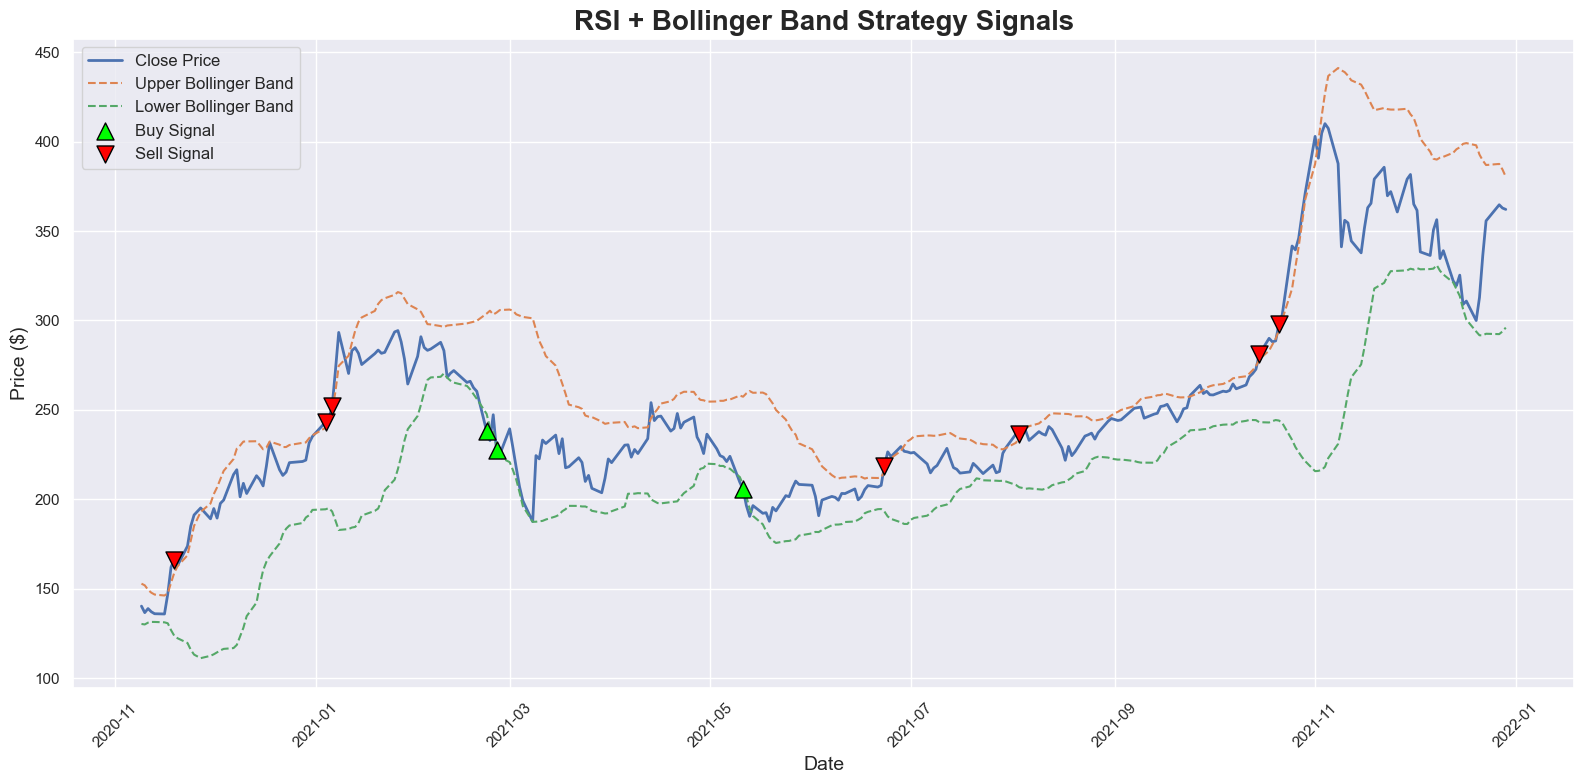

In [40]:
sns.set_theme(style="darkgrid")

# Create figure
plt.figure(figsize=(16,8))

# Plot Close Price
sns.lineplot(x=df.index, y=df['Close'][ticker], label='Close Price', linewidth=2)

# Plot Bollinger Bands
sns.lineplot(x=df.index, y=df['Upper_Band'], label='Upper Bollinger Band', linewidth=1.5, linestyle='--')
sns.lineplot(x=df.index, y=df['Lower_Band'], label='Lower Bollinger Band', linewidth=1.5, linestyle='--')

# Mark Buy Signals
buy_signals = df[df['Signal'] == 1]
plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='lime', s=150, edgecolor='black', label='Buy Signal', zorder=10)

# Mark Sell Signals
sell_signals = df[df['Signal'] == -1]
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', s=150, edgecolor='black', label='Sell Signal', zorder=10)

# Titles and labels
plt.title('RSI + Bollinger Band Strategy Signals', fontsize=20, weight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

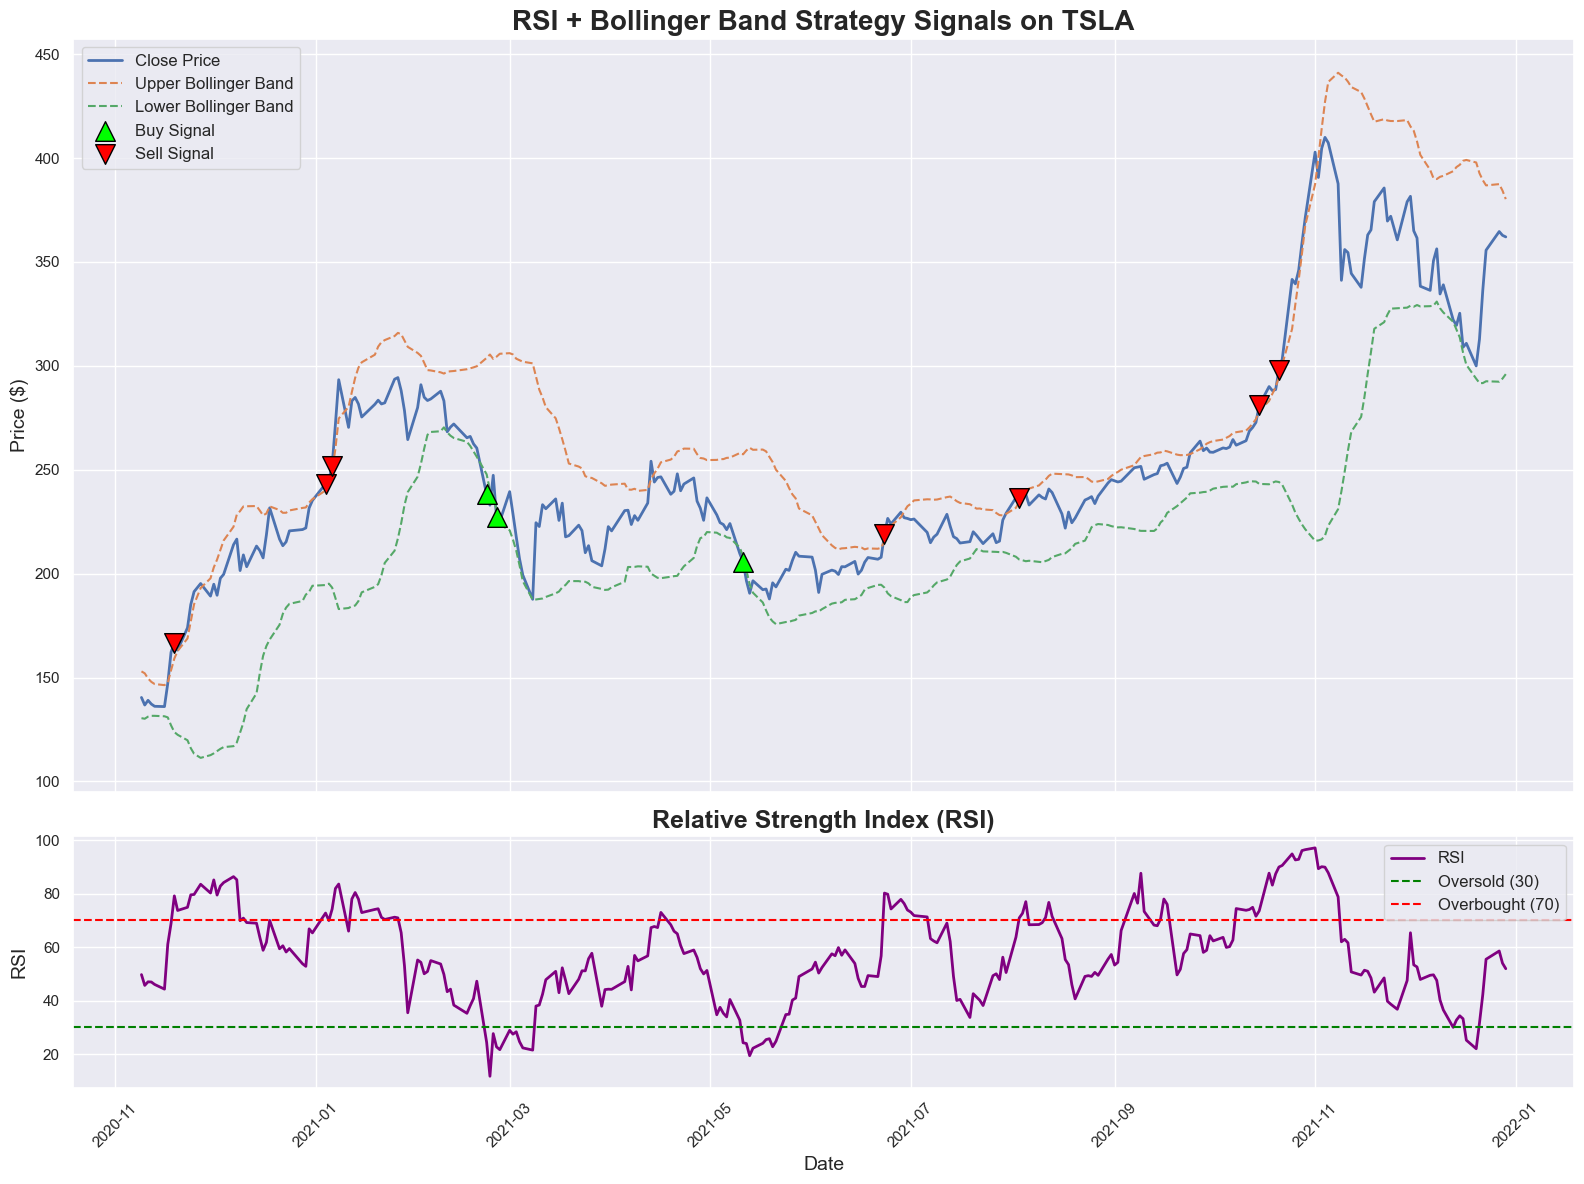

<Figure size 640x480 with 0 Axes>

In [41]:
sns.set_theme(style="darkgrid")


close_prices = df['Close'][ticker]


# Set up the figure with two subplots (top = price, bottom = RSI)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# === Top Plot: Close Price + Bollinger Bands + Signals ===
sns.lineplot(x=df.index, y=close_prices, label='Close Price', linewidth=2, ax=ax1)
sns.lineplot(x=df.index, y=df['Upper_Band'], label='Upper Bollinger Band', linewidth=1.5, linestyle='--', ax=ax1)
sns.lineplot(x=df.index, y=df['Lower_Band'], label='Lower Bollinger Band', linewidth=1.5, linestyle='--', ax=ax1)

# Mark Buy Signals
buy_signals = df[df['Signal'] == 1]
ax1.scatter(buy_signals.index, close_prices.loc[buy_signals.index], marker='^', color='lime', s=200, edgecolor='black', label='Buy Signal', zorder=10)

# Mark Sell Signals
sell_signals = df[df['Signal'] == -1]
ax1.scatter(sell_signals.index, close_prices.loc[sell_signals.index], marker='v', color='red', s=200, edgecolor='black', label='Sell Signal', zorder=10)

# Titles and labels for top plot
ax1.set_title(f'RSI + Bollinger Band Strategy Signals on {ticker}', fontsize=20, weight='bold')
ax1.set_ylabel('Price ($)', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True)

# === Bottom Plot: RSI ===
sns.lineplot(x=df.index, y=df['RSI'], label='RSI', color='purple', linewidth=2, ax=ax2)

# Add horizontal lines at 30 and 70
ax2.axhline(30, linestyle='--', color='green', label='Oversold (30)')
ax2.axhline(70, linestyle='--', color='red', label='Overbought (70)')

# Titles and labels for bottom plot
ax2.set_title('Relative Strength Index (RSI)', fontsize=18, weight='bold')
ax2.set_xlabel('Date', fontsize=14)
ax2.set_ylabel('RSI', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.savefig('RSI_BOLLINGER_TSLA_NEW.png')